In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../../data/raw/traffic.csv")

print(df["MM"].value_counts().head(10))
# timestamp
df["timestamp"] = pd.to_datetime(
    df["Yr"].astype(str) + "-" +
    df["M"].astype(str) + "-" +
    df["D"].astype(str) + " " +
    df["HH"].astype(str) + ":" +
    df["MM"].astype(str)
)

df["Vol"] = pd.to_numeric(df["Vol"], errors="coerce")

# 🔥 FIX: remove duplicates by aggregating
df = df.groupby("timestamp")["Vol"].mean().to_frame()

# full hourly index
full_range = pd.date_range(df.index.min(), df.index.max(), freq="h")
df = df.reindex(full_range)
df.index.name = "timestamp"


df["Vol"] = df["Vol"].replace(0, np.nan)
# interpolate missing
df["Vol"] = df["Vol"].interpolate(method="time")

df = df.reset_index()

MM
0     473659
15    466215
30    466210
45    466199
40       718
10       718
20       718
50       717
Name: count, dtype: int64


In [2]:
import matplotlib.pyplot as plt

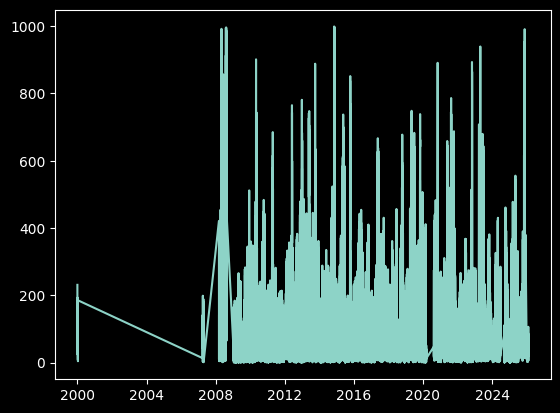

In [3]:
plt.plot(df["timestamp"], df["Vol"])

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 228744 entries, 0 to 228743
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   timestamp  228744 non-null  datetime64[us]
 1   Vol        228744 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 3.5 MB


In [5]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv("../../data/raw/traffic.csv")

# -----------------------------
# 2. CLEAN MINUTES
# (keep only valid 15-min intervals)
# -----------------------------
df = df[df["MM"].isin([0, 15, 30, 45])]

# -----------------------------
# 3. BUILD TIMESTAMP
# -----------------------------
df["timestamp"] = pd.to_datetime(
    df["Yr"].astype(str) + "-" +
    df["M"].astype(str) + "-" +
    df["D"].astype(str) + " " +
    df["HH"].astype(str) + ":" +
    df["MM"].astype(str)
)

df["Vol"] = pd.to_numeric(df["Vol"], errors="coerce")

# -----------------------------
# 4. AGGREGATE DUPLICATES
# (same timestamp → mean volume)
# -----------------------------
df = df.groupby("timestamp")["Vol"].mean().to_frame()

# -----------------------------
# 5. RESAMPLE TO HOURLY
# (THIS is the correct conversion step)
# -----------------------------
df = df.resample("h").mean()

# -----------------------------
# 6. CREATE FULL HOURLY INDEX
# -----------------------------
full_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="h"
)

df = df.reindex(full_range)

# -----------------------------
# 7. INTERPOLATE MISSING HOURS
# -----------------------------
df["Vol"] = df["Vol"].interpolate(method="time")

# -----------------------------
# 8. FINAL CLEANUP
# -----------------------------
df["Vol"] = df["Vol"].fillna(df["Vol"].median())

# force clean hourly index name
df.index.name = "timestamp"

# OPTIONAL: ensure clean alignment (no weird offsets)
df = df.reset_index()

# -----------------------------
# 9. DONE
# -----------------------------
print(df.head())

            timestamp         Vol
0 2000-01-01 00:00:00  198.833333
1 2000-01-01 01:00:00  169.875000
2 2000-01-01 02:00:00  186.000000
3 2000-01-01 03:00:00  187.625000
4 2000-01-01 04:00:00  171.000000


In [6]:
df[df['timestamp'] > '2025-12-15'].head(20)

,timestamp,Vol
227521,2025-12-15 01:00:00,248.181893
227522,2025-12-15 02:00:00,247.710339
227523,2025-12-15 03:00:00,247.238786
227524,2025-12-15 04:00:00,246.767232
227525,2025-12-15 05:00:00,246.295678
227526,2025-12-15 06:00:00,245.824125
227527,2025-12-15 07:00:00,245.352571
227528,2025-12-15 08:00:00,244.881018
227529,2025-12-15 09:00:00,244.409464
227530,2025-12-15 10:00:00,243.937910


In [34]:
df.to_csv("../../data/interim/traffic_imputed.csv", index=False)